In [2]:
# ============================================
# BANK CHURN ANALYTICS - Day 10
# K-Means Clustering & Customer Personas
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load cleaned dataset
df = pd.read_csv(r'D:\Python project\data\European_Bank_Cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (10000, 19)


In [3]:
# Select features for clustering
cluster_features = ['Age', 'Balance', 'NumOfProducts', 
                    'IsActiveMember', 'EstimatedSalary',
                    'Tenure', 'CreditScore', 'CLV_Score',
                    'EngagementScore']

X = df[cluster_features].copy()

# Scale features — CRITICAL for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
for f in cluster_features:
    print(f"  → {f}")
print(f"\nScaled array shape: {X_scaled.shape}")

Features selected for clustering:
  → Age
  → Balance
  → NumOfProducts
  → IsActiveMember
  → EstimatedSalary
  → Tenure
  → CreditScore
  → CLV_Score
  → EngagementScore

Scaled array shape: (10000, 9)


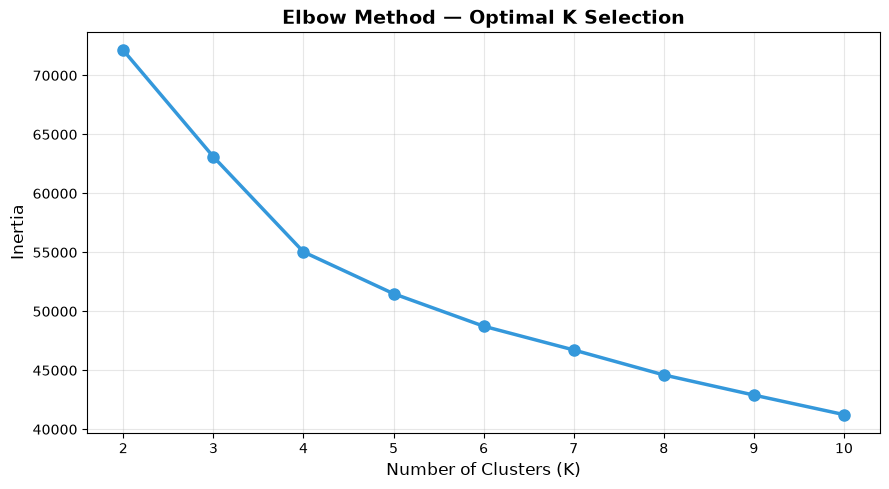

Chart saved!


In [4]:
# ELBOW METHOD — Find optimal K
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, inertias, 'bo-', linewidth=2.5, 
        markersize=8, color='#3498db')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Optimal K Selection', 
              fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\20_elbow_method.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

K=2 | Silhouette Score: 0.2008
K=3 | Silhouette Score: 0.1785
K=4 | Silhouette Score: 0.2053
K=5 | Silhouette Score: 0.2065
K=6 | Silhouette Score: 0.1881
K=7 | Silhouette Score: 0.1762
K=8 | Silhouette Score: 0.1788
K=9 | Silhouette Score: 0.1697
K=10 | Silhouette Score: 0.1738


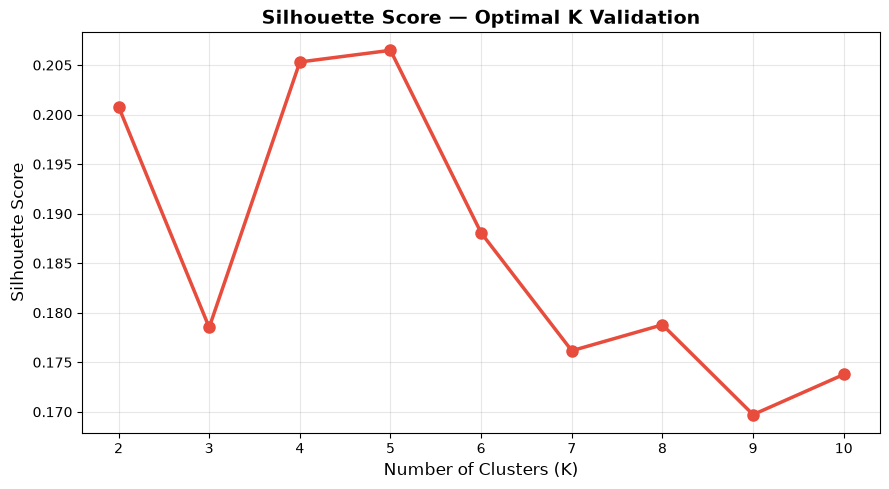


Best K: 5


In [5]:
# SILHOUETTE SCORE — Validate optimal K
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, silhouette_scores, 'bo-', linewidth=2.5,
        markersize=8, color='#e74c3c')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score — Optimal K Validation',
              fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\21_silhouette_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nBest K:", k_range[silhouette_scores.index(max(silhouette_scores))])

In [6]:
# TRAIN FINAL K-MEANS MODEL (K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means trained with K={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Churn rate per cluster
print(f"\nChurn rate per cluster:")
cluster_churn = df.groupby('Cluster')['Exited'].agg(['mean', 'count', 'sum'])
cluster_churn.columns = ['ChurnRate', 'Total', 'Churned']
cluster_churn['ChurnRate'] = (cluster_churn['ChurnRate'] * 100).round(2)
print(cluster_churn)

K-Means trained with K=4

Cluster distribution:
Cluster
0    3024
1    2127
2    1918
3    2931
Name: count, dtype: int64

Churn rate per cluster:
         ChurnRate  Total  Churned
Cluster                           
0            15.94   3024      482
1            11.89   2127      253
2            20.23   1918      388
3            31.18   2931      914


In [7]:
# CLUSTER PROFILING
profile_cols = ['Age', 'Balance', 'NumOfProducts', 'IsActiveMember',
                'EstimatedSalary', 'Tenure', 'CreditScore', 
                'CLV_Score', 'EngagementScore', 'Exited']

cluster_profiles = df.groupby('Cluster')[profile_cols].mean().round(2)
print("CLUSTER PROFILES — MEAN VALUES")
print("=" * 70)
print(cluster_profiles.to_string())

# Geography and Gender distribution per cluster
print("\nGEOGRAPHY DISTRIBUTION PER CLUSTER:")
print(pd.crosstab(df['Cluster'], df['Geography'], normalize='index').round(3) * 100)

print("\nGENDER DISTRIBUTION PER CLUSTER:")
print(pd.crosstab(df['Cluster'], df['Gender'], normalize='index').round(3) * 100)

CLUSTER PROFILES — MEAN VALUES
           Age    Balance  NumOfProducts  IsActiveMember  EstimatedSalary  Tenure  CreditScore  CLV_Score  EngagementScore  Exited
Cluster                                                                                                                           
0        39.73  122217.78           1.31             1.0        102990.82    4.85       654.54   92975.78             1.31    0.16
1        39.87    9989.54           1.85             1.0         94423.13    5.05       650.65   34332.52             1.85    0.12
2        37.18    6684.09           1.79             0.0         95439.59    5.07       648.34   32987.89             0.00    0.20
3        38.53  123235.93           1.35             0.0        104253.51    5.12       647.73   93917.08             0.00    0.31

GEOGRAPHY DISTRIBUTION PER CLUSTER:
Geography  France  Germany  Spain
Cluster                          
0            40.8     37.1   22.1
1            63.8      5.9   30.3
2         

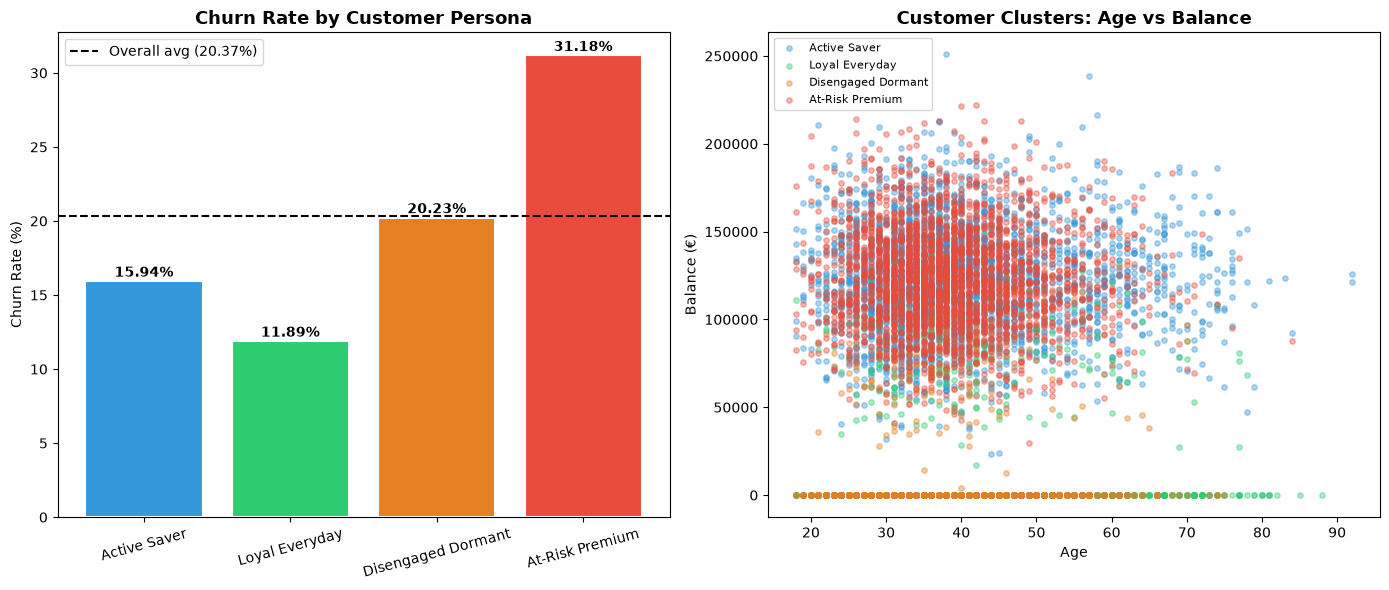

Chart saved!


In [8]:
# CLUSTER VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
labels = ['Active Saver', 'Loyal Everyday', 
          'Disengaged Dormant', 'At-Risk Premium']

# Chart 1 — Churn rate by cluster
churn_rates = cluster_churn['ChurnRate']
bars = axes[0].bar(labels, churn_rates, color=colors, 
                    edgecolor='white', linewidth=1.5)
axes[0].axhline(y=20.37, color='black', linestyle='--',
                 linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, churn_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.3,
                  f'{rate}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Customer Persona',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

# Chart 2 — Balance vs Age scatter colored by cluster
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = df['Cluster'] == i
    axes[1].scatter(df[mask]['Age'], df[mask]['Balance'],
                     c=color, label=label, alpha=0.4, s=15)
axes[1].set_title('Customer Clusters: Age vs Balance',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Balance (€)')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(r'D:\Python project\reports\22_cluster_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
# Save dataset with cluster labels
df.to_csv(r'D:\Python project\data\European_Bank_Clustered.csv', index=False)
print("Clustered dataset saved!")
print(f"Shape: {df.shape}")
print(f"\nCluster label distribution:")
print(df['Cluster'].value_counts().sort_index())

# Final Day 10 summary
print("\n" + "=" * 55)
print("DAY 10 — CLUSTERING SUMMARY")
print("=" * 55)
print("""
Optimal K: 4 (Elbow=4, Silhouette K=4 score=0.2053)

CUSTOMER PERSONAS:
  Cluster 0 — Active Saver       : 15.94% churn | 3,024 customers
  Cluster 1 — Loyal Everyday     : 11.89% churn | 2,127 customers
  Cluster 2 — Disengaged Dormant : 20.23% churn | 1,918 customers
  Cluster 3 — At-Risk Premium    : 31.18% churn | 2,931 customers

KEY INSIGHT: Balance is identical in Clusters 0 & 3.
Engagement alone explains 15.94% vs 31.18% churn.
Re-engaging At-Risk Premium = highest ROI intervention.
""")

Clustered dataset saved!
Shape: (10000, 20)

Cluster label distribution:
Cluster
0    3024
1    2127
2    1918
3    2931
Name: count, dtype: int64

DAY 10 — CLUSTERING SUMMARY

Optimal K: 4 (Elbow=4, Silhouette K=4 score=0.2053)

CUSTOMER PERSONAS:
  Cluster 0 — Active Saver       : 15.94% churn | 3,024 customers
  Cluster 1 — Loyal Everyday     : 11.89% churn | 2,127 customers
  Cluster 2 — Disengaged Dormant : 20.23% churn | 1,918 customers
  Cluster 3 — At-Risk Premium    : 31.18% churn | 2,931 customers

KEY INSIGHT: Balance is identical in Clusters 0 & 3.
Engagement alone explains 15.94% vs 31.18% churn.
Re-engaging At-Risk Premium = highest ROI intervention.

